Latent data shape for digit 0: (1000, 32)
Latent data shape for digit 1: (1000, 32)
Latent data shape for digit 2: (1000, 32)
Latent data shape for digit 3: (1000, 32)
Latent data shape for digit 4: (1000, 32)
Latent data shape for digit 5: (1000, 32)
Latent data shape for digit 6: (1000, 32)
Latent data shape for digit 7: (1000, 32)
Latent data shape for digit 8: (1000, 32)
Latent data shape for digit 9: (1000, 32)


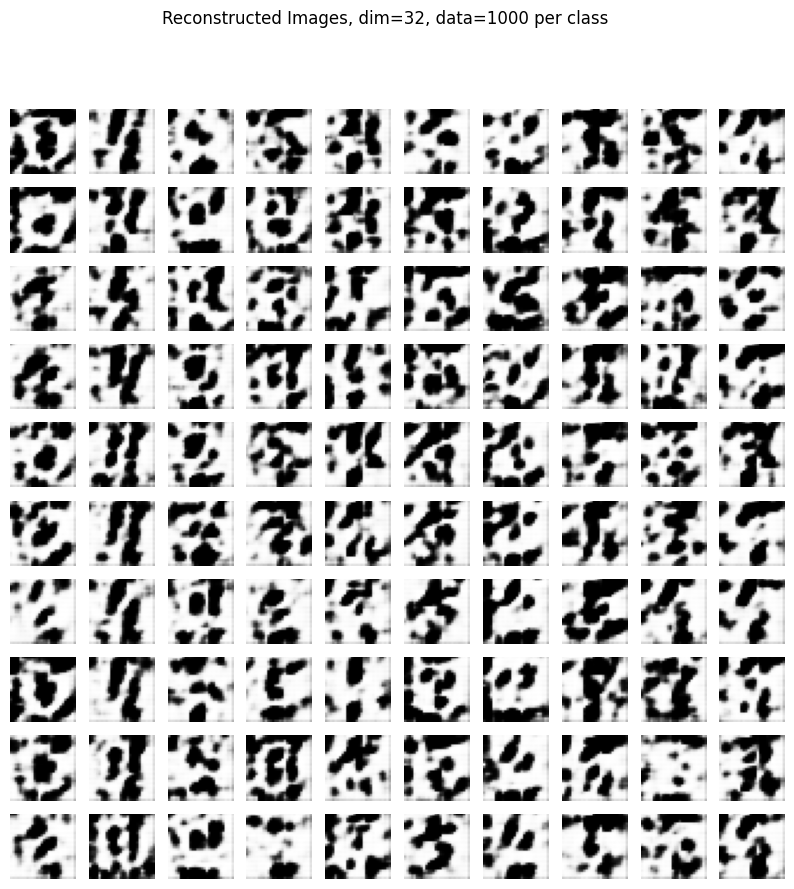

In [37]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import importlib

from modules import Autoencoder
importlib.reload(Autoencoder)  # 모듈 갱신

# 오토인코더 모델 로드
latent_dim = 32
autoencoder = Autoencoder.Autoencoder(latent_dim=latent_dim)
autoencoder.load_state_dict(torch.load('savepoints/autoencoder.pth'))
autoencoder.eval()  # 평가 모드로 전환

num_images_per_class = 1000

# 데이터 로드
data = np.load(f'./data/MNIST/mnist_{num_images_per_class}.npz')

# 클래스별로 10개의 latent 벡터를 선택하고 복원
reconstructed_images = []
for digit in range(10):
    latent_data = data[f'{digit}_latent']  # 각 클래스의 latent 벡터 불러오기
    
    print(f"Latent data shape for digit {digit}:", latent_data.shape)
    # 10개의 latent 벡터를 텐서로 변환
    latent_vectors = torch.tensor(latent_data[:10], dtype=torch.float32)
    
    # 오토인코더의 디코더로 복원
    with torch.no_grad():
        reconstructed = autoencoder.decoder(latent_vectors)  # (10, 1, 28, 28)
    reconstructed_images.append(reconstructed)

# 10x10 그리드에 시각화
fig, axs = plt.subplots(10, 10, figsize=(10, 10))
for i in range(10):
    for j in range(10):
        # (1, 28, 28) 형태를 (28, 28)으로 변환하여 시각화
        axs[j, i].imshow(reconstructed_images[i][j].squeeze().detach().numpy(), cmap='gray')
        axs[j, i].axis('off')

plt.suptitle(f"Reconstructed Images, dim={latent_dim}, data={num_images_per_class} per class")
plt.show()


In [35]:
reconstructed_images[0][0].numpy()[0]

array([3.1437848e-02, 2.3571798e-01, 6.7569500e-01, 9.3770742e-01,
       9.7525853e-01, 9.7628480e-01, 9.2847067e-01, 5.7586497e-01,
       1.5771089e-01, 4.2523339e-01, 4.1259986e-01, 1.3129152e-01,
       6.0287975e-03, 1.1900438e-05, 1.4404218e-07, 1.7846865e-07,
       1.6682701e-05, 2.2999094e-09, 8.2185116e-13, 6.9177865e-14,
       8.7466173e-11, 4.1810413e-09, 1.8580326e-06, 9.5796728e-05,
       2.5290344e-03, 4.4714655e-03, 5.7947859e-02, 1.8088818e-01],
      dtype=float32)